# Decision Tree Regression

Decision Tree Regression, instead of Classification, is a method to predict continous values like prices or scores by using a tree-like structure. It works by splitting the data into smaller parts based on simple rules taken from the input features. These splits help reduce errors in prediction

Art the end of each branch, which come to the leaf nodes that we have discussed recently, the model gives a prediction usually the average value of that group

again, im bad at explaining this, let my demonstaration do the work again

shout out to https://www.geeksforgeeks.org/machine-learning/python-decision-tree-regression-using-sklearn/ for teaching me this


In a decision tree, information gain (IG) ***measures how much a particular feature helps to reduce uncertainty (or entropy) when classifying data***. It quantifies the effectiveness of splitting the dataset based on a feature.

Information Gain is the difference between the uncertainty (entropy) before and after a split. In other words, it's like saying, “Did this split help us make better predictions?” ***The higher the Information Gain, the better the split.***

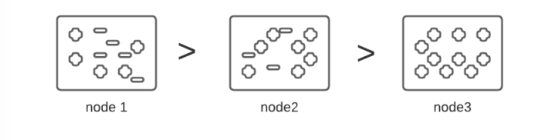

As we can see in these three nodes we have data of two classes and here in node 3 we have data for only one class and similarly, we have less data for the second class than the first class in node 2, and node 1 is balanced. By this above, we can say that ***in node three we don’t need to make any decision*** because all the instances are representing the direction of the decision in the class first side wherein in ***node 1 there are 50% chances to decide the direction of both classes***. We can say that in node 1 we are required more information than the other nodes to describe a decision. By the above, we can say the information gain in node 1 is higher.

By the above, we can say the balanced nodes or most impure nodes require more information to describe. Let’s take a look at the below image on two nodes with different impurities.

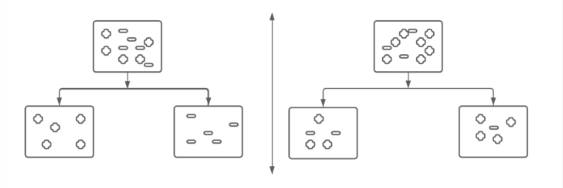




- Mathematical calculation:

We have $S$ is a set of data point. With $S$ contains $N$ data points
$$
H(S) = -\sum^{C}_{c=1}\frac{N_c}{N}log_2(\frac{N_c}{N})
$$
or this is just pure enthropy

and assume we choose attribute $x$ for this node and $x$ can create $K$ child nodes $S_1,s_2,s_3,...S_k$ with number of each child node are $m_1,m_2,...,m_k$

$$
H(x,S) = \sum^{K}_{k=1}\frac{m_k}{N}H(S_k) = -\sum^{K}_{k=1}\frac{m_k}{N}\sum^{C}_{c=1}\frac{m_k}{N}log_2(\frac{m_k}{N})
$$

and the information gain on x is calculated by:
$$
G(x,S) = H(S) - H(x,S) = -\sum^{C}_{c=1}\frac{N_c}{N}log_2(\frac{N_c}{N}) -  \sum^{K}_{k=1}\frac{m_k}{N}H(S_k)
$$

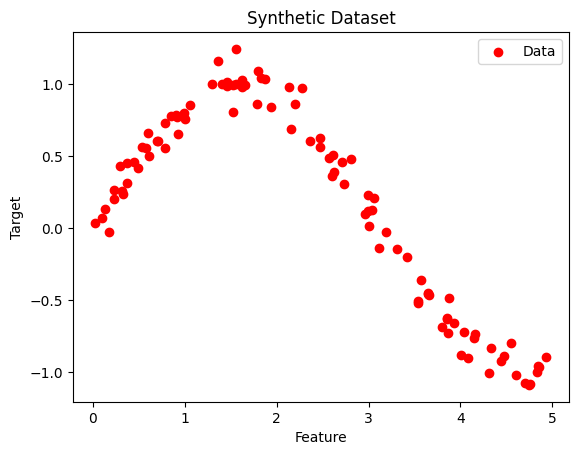

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_text, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, median_absolute_error

np.random.seed(42)
x = np.sort(5 * np.random.rand(100, 1), axis=0)
y = np.sin(x).ravel() + np.random.normal(0, 0.1, x.shape[0])
#the ravel thing make the np.sin() become a 1D array

plt.scatter(x, y, color='red', label='Data')
plt.title("Synthetic Dataset")
plt.xlabel("Feature")
plt.ylabel("Target")
plt.legend()
plt.show()

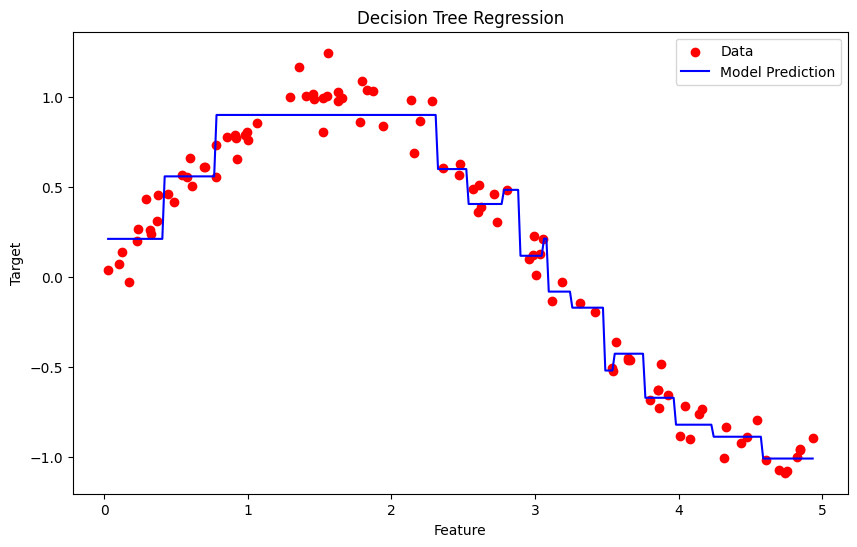

Mean Absolute Error: 0.09888368084921427
R-squared: 0.9679025510927086


In [22]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

DecisionTreeRegressor_model = DecisionTreeRegressor(max_depth = 4, random_state=42)
DecisionTreeRegressor_model.fit(x_train, y_train)
y_predict = DecisionTreeRegressor_model.predict(x_test)

mse = mean_absolute_error(y_test, y_predict)
r2 = r2_score(y_test, y_predict)

x_grid = np.linspace(min(x), max(x), 300).reshape(-1, 1)
y_grid_pred = DecisionTreeRegressor_model.predict(x_grid)
'''
this is basically the newer data sets that is like more data points, thus increase
the accuracy of the model and the smoothing sensation of the line plot, instead of predicting
the whole given datasets.

This servers for accuracy checking and plot demonstration
'''

plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='red', label='Data')
plt.plot(x_grid, y_grid_pred, color='blue', label='Model Prediction')
plt.title("Decision Tree Regression")
plt.xlabel("Feature")
plt.ylabel("Target")
plt.legend()
plt.show()

'''
as you can see from the plot, the plot doesn't seems to go by the average indicator, instead, it "fluctuating",
each drops indicate each differences, so do each climbing up, and for every single drop and climb, it basically
indicates each leaf nodes.

By that, the decision tree regression are based on this climbing and dropping foundation: based on the certain
criteria, in this case, criteria means each rows or each nodes not enthopy, we can conclude the output
'''
print(f"Mean Absolute Error: {mse}")
print(f"R-squared: {r2}")
#the model is relatively accurate

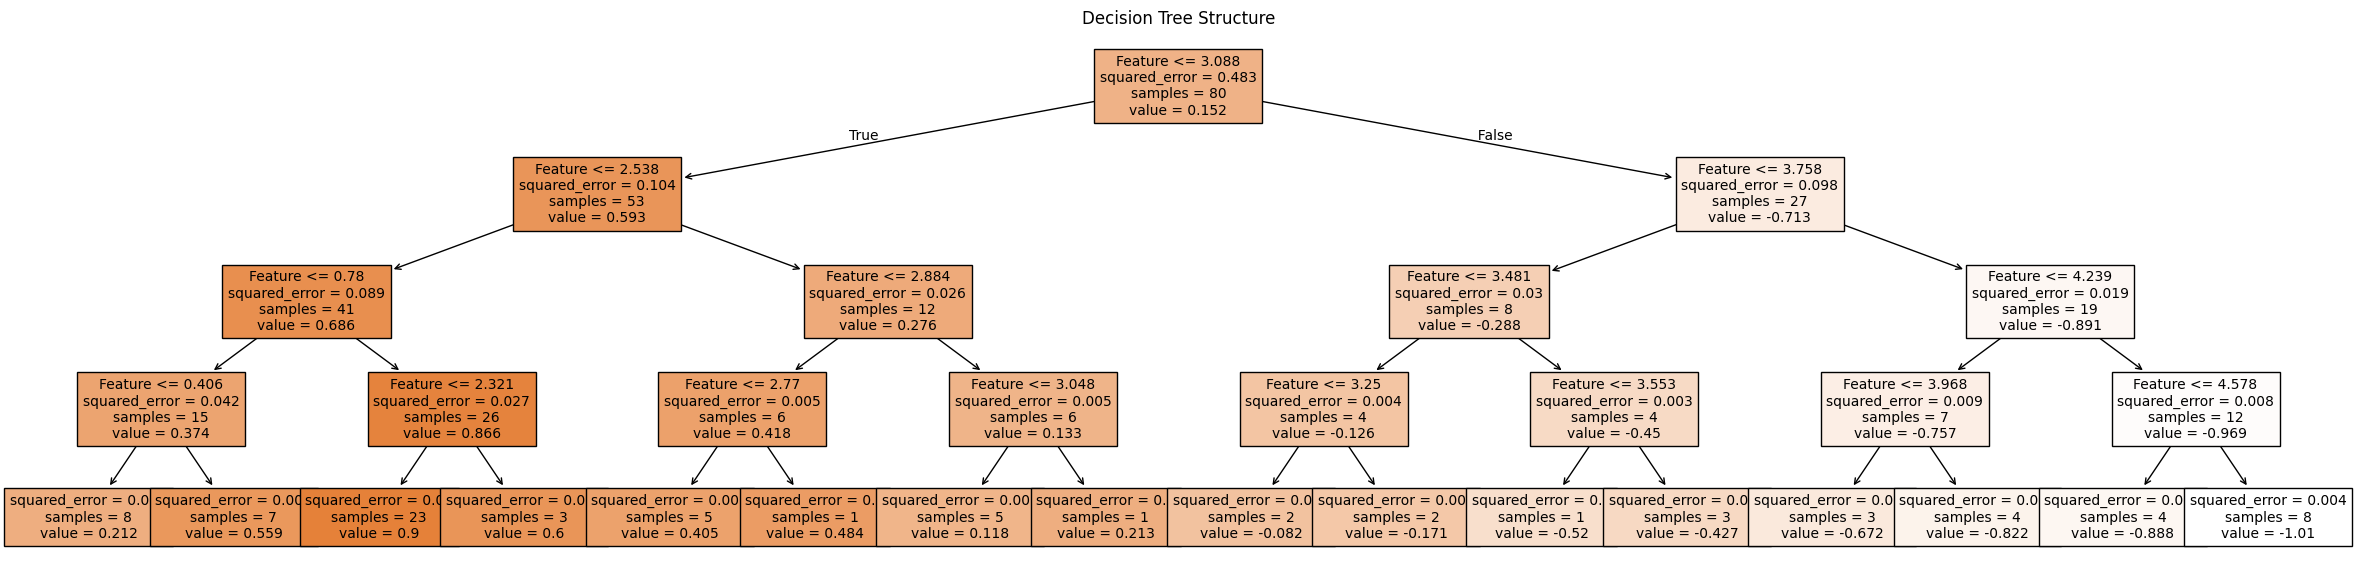

In [23]:
from sklearn.tree import plot_tree

plt.figure(figsize=(30, 7))
plot_tree(
    DecisionTreeRegressor_model,
    feature_names=["Feature"],
    filled=True,
    fontsize=10
)
plt.title("Decision Tree Structure")
plt.show()

In [24]:
from sklearn.metrics import mean_squared_error, median_absolute_error, r2_score
import math
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor #***************************************************************
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor #***************************************************************
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def getScores( y_test, y_predict):
    mse = mean_squared_error(y_test,y_predict)
    rmse = math.sqrt(mse)
    mae = median_absolute_error(y_test,y_predict)
    r2 = r2_score(y_test,y_predict)
    result = {"MSE": mse, "RMSE": rmse, "MAE": mae, "R2_Score": r2 }
    return result

def Auto_Bagging_MachineLearning_Model(Type_of_MachineLearning_model,
                                       x_train, x_test, y_train, y_test):
  model_name = Type_of_MachineLearning_model()
  model_name.fit(x_train,y_train)
  y_prediction = model_name.predict(x_test)
  result = f"Accuracy Calculation of {Type_of_MachineLearning_model.__name__} are: {getScores(y_test, y_prediction)}"
  return result


insurance_dataset = pd.read_csv("/home/ducanh19082007/Quantitative_Finance_Self_Learning/Data/0.Data_Sets/insurance.csv")

# Use one-hot encoding for categorical variables
insurance_dataset = pd.get_dummies(insurance_dataset, columns=['sex', 'smoker', 'region'], drop_first=True)

x = insurance_dataset.drop(["charges"], axis=1)
y = insurance_dataset["charges"]
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)


print(Auto_Bagging_MachineLearning_Model(DecisionTreeRegressor,
                                         x_train, x_test, y_train, y_test))

print(Auto_Bagging_MachineLearning_Model(LinearRegression,
                                         x_train, x_test, y_train, y_test))

print(Auto_Bagging_MachineLearning_Model(RandomForestRegressor,
                                         x_train, x_test, y_train, y_test))

Accuracy Calculation of DecisionTreeRegressor are: {'MSE': 46426407.344600394, 'RMSE': 6813.692636493108, 'MAE': 582.132325, 'R2_Score': 0.7009546751300799}
Accuracy Calculation of LinearRegression are: {'MSE': 33596915.85136145, 'RMSE': 5796.284659276273, 'MAE': 2695.139463039106, 'R2_Score': 0.7835929767120724}
Accuracy Calculation of RandomForestRegressor are: {'MSE': 21102748.19535533, 'RMSE': 4593.772762703367, 'MAE': 1234.0792557500135, 'R2_Score': 0.8640713647539623}


In [25]:
# Debug: Check data types after encoding
print("Data types after encoding:")
print(insurance_dataset.dtypes)
print("\nFirst few rows:")
print(insurance_dataset.head())

Data types after encoding:
age                   int64
bmi                 float64
children              int64
charges             float64
sex_male               bool
smoker_yes             bool
region_northwest       bool
region_southeast       bool
region_southwest       bool
dtype: object

First few rows:
   age     bmi  children      charges  sex_male  smoker_yes  region_northwest  \
0   19  27.900         0  16884.92400     False        True             False   
1   18  33.770         1   1725.55230      True       False             False   
2   28  33.000         3   4449.46200      True       False             False   
3   33  22.705         0  21984.47061      True       False              True   
4   32  28.880         0   3866.85520      True       False              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4  